# Laboratorio #1 — Preparación de un corpus y EDA
**Natural Language Processing — UFM**


In [45]:
# Librerias base
import re
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Recursos de NLTK (solo se descargan la primera vez)
nltk.download("punkt_tab", quiet=True)   # reglas de tokenizacion
nltk.download("stopwords", quiet=True)   # listas de palabras vacias

# Carpeta donde guardaremos las figuras para el reporte en Word
from pathlib import Path
FIG = Path("figuras")
FIG.mkdir(exist_ok=True)

# Para poder leer textos largos completos en las celdas
pd.set_option("display.max_colwidth", 300)

print("Entorno listo")

Entorno listo


In [46]:
df = pd.read_csv("df_total.csv")

df.head(3)

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colombia Andrés García aseguró que es importante entender que la sostenibilidad no la podemos asociar a mayores costos. Yo creo que el no tener un concepto ...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bolsa en el extranjero luego de que supervisores estadounidenses endurecieron las exigencias de divulgación de información para las empresas chinas y ex...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la lucha contra el cáncer de mama la inclusión y la diversidad.Desde Francia llegó Go Pink que tuvo un precio promedio de US50 millones convirtiéndose en la...,Alianzas


### 2.1 ¿Cuántos documentos tiene el corpus?

In [47]:
n_documentos = df.shape[0]
print(f"El corpus tiene {n_documentos} documentos (noticias).")

El corpus tiene 1217 documentos (noticias).


### 2.2 ¿Qué columnas contiene y qué información guarda cada una?

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     1217 non-null   str  
 1   news    1217 non-null   str  
 2   Type    1217 non-null   str  
dtypes: str(3)
memory usage: 28.7 KB


In [49]:
df.describe(include="object")

/var/folders/b7/rmh5zsw16z55ywlgyckwskqh0000gn/T/ipykernel_20946/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,url,news,Type
count,1217,1217,1217
unique,1101,1138,7
top,https://www.bbva.com/es/bbva-spark-la-nueva-banca-para-las-empresas-innovadoras-de-alto-crecimiento/,,Macroeconomia
freq,5,4,340


In [50]:
print("URL   :", df["url"].iloc[0])
print("TIPO  :", df["Type"].iloc[0])
print("NEWS  :", df["news"].iloc[0][:600], "...")

URL   : https://www.larepublica.co/redirect/post/3201905
TIPO  : Otra
NEWS  : Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colombia Andrés García aseguró que es importante entender que la sostenibilidad no la podemos asociar a mayores costos. Yo creo que el no tener un concepto de negocio sostenible puede tener un mayor impacto de lo que imaginamos.Para García el reto más importante es no cambiar prioridades ni que compitan entre sí necesariamente. En muchos de los casos se debe tratar de mantener la prioridad en cuanto a la ambición de negocios más sostenibles un reto enorme  ...


**Interpretación de las columnas:**

| Columna | Tipo | Qué guarda |
|---|---|---|
| `url` | texto | Enlace a la noticia original (metadato, no es texto a analizar) |
| `news` | texto | **Cuerpo de la noticia.** Es la columna que constituye el corpus |
| `Type` | texto | **Categoría** temática de la noticia (variable de clasificación) |


### 2.3 ¿Cuántas categorías hay y cómo se distribuyen?

In [51]:
n_categorias = df["Type"].nunique()
print(f"Hay {n_categorias} categorias distintas.\n")

# Distribucion absoluta y relativa (para juzgar si el corpus esta balanceado)
distribucion = pd.DataFrame({
    "documentos": df["Type"].value_counts(),
    "porcentaje": (df["Type"].value_counts(normalize=True) * 100).round(2),
})
distribucion

Hay 7 categorias distintas.



,documentos,porcentaje
Type,,
Macroeconomia,340,27.94
Alianzas,247,20.30
Innovacion,195,16.02
Regulaciones,142,11.67
Sostenibilidad,137,11.26
Otra,130,10.68
Reputacion,26,2.14


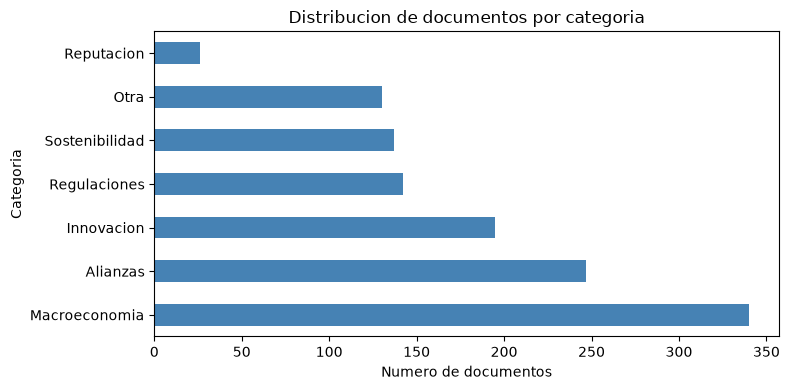

In [52]:
ax = df["Type"].value_counts().plot(kind="barh", figsize=(8, 4), color="steelblue")
ax.set_title("Distribucion de documentos por categoria")
ax.set_xlabel("Numero de documentos")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.savefig(FIG / "01_distribucion_categorias.png", dpi=150)
plt.show()

### 2.4 ¿Hay filas vacías o duplicadas?

In [53]:
print("--- Valores nulos por columna ---")
print(df.isna().sum())

# Vacios "falsos": strings de longitud 0 o solo espacios; isna() NO los detecta
vacios = df["news"].astype(str).str.strip().eq("").sum()
print(f"\nTextos vacios o solo espacios en 'news': {vacios}")

print(f"\nFilas completamente duplicadas : {df.duplicated().sum()}")
print(f"Textos de noticia duplicados   : {df.duplicated(subset=['news']).sum()}")

--- Valores nulos por columna ---
url     0
news    0
Type    0
dtype: int64

Textos vacios o solo espacios en 'news': 4

Filas completamente duplicadas : 75
Textos de noticia duplicados   : 79


In [54]:
# Un texto repetido con dos categorias distintas es un conflicto de etiquetas
dups = df[df.duplicated(subset=["news"], keep=False)]
if len(dups) > 0:
    conflicto = dups.groupby("news")["Type"].nunique()
    print(f"Textos repetidos con MAS DE UNA categoria: {(conflicto > 1).sum()}")
else:
    print("No hay textos duplicados.")

Textos repetidos con MAS DE UNA categoria: 4


In [55]:
# Guardamos el conteo antes/despues para reportar cuanto se elimino
antes = len(df)

df = df.dropna(subset=["news", "Type"])
df = df[df["news"].astype(str).str.strip() != ""]
df = df.drop_duplicates(subset=["news"], keep="first").reset_index(drop=True)

despues = len(df)
print(f"Documentos antes de limpiar : {antes}")
print(f"Documentos despues de limpiar: {despues}")
print(f"Eliminados: {antes - despues} ({(antes-despues)/antes*100:.2f}%)")

Documentos antes de limpiar : 1217
Documentos despues de limpiar: 1137
Eliminados: 80 (6.57%)


---
## 3. Preparación del corpus

Aplicamos el pipeline de normalización visto en clase, **en este orden**, y después de cada
paso contamos cuántos **tokens** y cuántos **tipos** (palabras distintas) quedan.

> **Tokens** = cada ocurrencia de una palabra, incluidas las repeticiones.
> **Tipos** = palabras distintas del vocabulario; cada tipo se cuenta una sola vez.

Guardamos **una columna nueva por paso** para poder inspeccionar y comparar cualquier etapa.

In [56]:
def contar(serie_de_listas):
    """Devuelve (total de tokens, tamano del vocabulario) de una columna de listas."""
    total_tokens = int(serie_de_listas.str.len().sum())
    vocabulario = Counter(t for lista in serie_de_listas for t in lista)
    return total_tokens, len(vocabulario)

registro = []

def registrar(paso, serie):
    tokens, tipos = contar(serie)
    registro.append({"paso": paso, "tokens": tokens, "tipos": tipos})
    print(f"{paso:<28} tokens={tokens:>9,}   tipos={tipos:>8,}")

### i. Tokenización

In [57]:
# Usamos el tokenizador POR REGLAS LINGUISTICAS de NLTK (no split por espacios),
# porque separa la puntuacion pegada a la palabra e incluye los signos ¿ ¡ del espanol.
df["tok_1_tokenizado"] = df["news"].astype(str).apply(
    lambda t: word_tokenize(t, language="spanish")
)

registrar("i. Tokenizacion", df["tok_1_tokenizado"])
df["tok_1_tokenizado"].iloc[0][:25]

i. Tokenizacion              tokens=  631,740   tipos=  38,941


['Durante',
 'el',
 'foro',
 'La',
 'banca',
 'articulador',
 'empresarial',
 'para',
 'el',
 'desarrollo',
 'sostenible',
 'el',
 'director',
 'de',
 'sostenibilidad',
 'y',
 'clientes',
 'globales',
 'de',
 'BBVA',
 'en',
 'Colombia',
 'Andrés',
 'García',
 'aseguró']

In [58]:
# Comparacion contra la tokenizacion ingenua por espacios en blanco
ejemplo = df["news"].iloc[0][:120]
print("TEXTO   :", ejemplo)
print()
print("split() :", ejemplo.split()[:15])
print()
print("NLTK    :", word_tokenize(ejemplo, language="spanish")[:15])

TEXTO   : Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes 

split() : ['Durante', 'el', 'foro', 'La', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad']

NLTK    : ['Durante', 'el', 'foro', 'La', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad']


### ii. Minúsculas

In [59]:
# Unificamos variantes: "Casa" y "casa" pasan a ser el mismo tipo.
# Nota: esto colapsa entidades con nombres comunes ("Banco" vs "banco").
df["tok_2_minusculas"] = df["tok_1_tokenizado"].apply(
    lambda tokens: [t.lower() for t in tokens]
)

registrar("ii. Minusculas", df["tok_2_minusculas"])

ii. Minusculas               tokens=  631,740   tipos=  36,093


### iii. Eliminar puntuación

In [60]:
# string.punctuation es ASCII: NO incluye ¿ ¡ « » — “ ” …
# Por eso ampliamos el conjunto a mano (desafio propio del espanol).
PUNTUACION = set(string.punctuation) | set("¿¡«»—–“”‘’…´`")
print("Signos considerados:", "".join(sorted(PUNTUACION)))

# Medimos cuantos tokens numericos hay, para saber que perdemos con isalpha()
todos = [t for lista in df["tok_2_minusculas"] for t in lista]
print(f"\nTokens puramente numericos: {sum(1 for t in todos if t.isdigit()):,}")
print(f"Tokens de solo puntuacion : {sum(1 for t in todos if all(c in PUNTUACION for c in t)):,}")
del todos

Signos considerados: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~¡«´»¿–—‘’“”…

Tokens puramente numericos: 9,879
Tokens de solo puntuacion : 33,361


In [61]:
# Criterio elegido: conservamos solo tokens alfabeticos (isalpha()).
# Esto elimina signos de puntuacion Y numeros; lo documentamos en el reporte.
df["tok_3_sin_punt"] = df["tok_2_minusculas"].apply(
    lambda tokens: [t for t in tokens if t.isalpha()]
)

registrar("iii. Sin puntuacion", df["tok_3_sin_punt"])

iii. Sin puntuacion          tokens=  578,707   tipos=  27,315


### iv. Eliminar stopwords

In [62]:
# Lista de stopwords del espanol de NLTK. La convertimos a SET:
# con una lista, el operador "in" es O(n) por token y sobre cientos de miles se nota.
STOPWORDS_ES = set(stopwords.words("spanish"))
print(f"Stopwords del espanol en NLTK: {len(STOPWORDS_ES)}")
print(sorted(STOPWORDS_ES)[:30])

# Nota: vienen CON tilde ("está", "más", "sí"). Si se quitaran los acentos del corpus,
# habria que quitarselos tambien a esta lista o no filtrarian nada.
print("\n¿'está' en la lista?", "está" in STOPWORDS_ES)
print("¿'esta' en la lista? ", "esta" in STOPWORDS_ES)

Stopwords del espanol en NLTK: 313
['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella', 'ellas', 'ellos', 'en', 'entre', 'era', 'erais', 'eran', 'eras', 'eres', 'es']

¿'está' en la lista? True
¿'esta' en la lista?  True


In [63]:
df["tok_4_sin_stop"] = df["tok_3_sin_punt"].apply(
    lambda tokens: [t for t in tokens if t not in STOPWORDS_ES]
)

registrar("iv. Sin stopwords", df["tok_4_sin_stop"])

iv. Sin stopwords            tokens=  299,283   tipos=  27,104


In [64]:
# Efecto de quitar stopwords sobre el SIGNIFICADO: la negacion "no" es stopword.
print("'no' es stopword: ", "no" in STOPWORDS_ES)
print("'ni' es stopword: ", "ni" in STOPWORDS_ES)
print("'sin' es stopword:", "sin" in STOPWORDS_ES)

# Buscamos una noticia real que contenga una negacion y vemos como queda
for i in range(len(df)):
    if "no" in df["tok_3_sin_punt"].iloc[i][:40]:
        print("\nANTES :", df["tok_3_sin_punt"].iloc[i][:25])
        print("DESPUES:", df["tok_4_sin_stop"].iloc[i][:25])
        break

'no' es stopword:  True
'ni' es stopword:  True
'sin' es stopword: True

ANTES : ['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva', 'en', 'colombia', 'andrés', 'garcía', 'aseguró']
DESPUES: ['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia', 'andrés', 'garcía', 'aseguró', 'importante', 'entender', 'sostenibilidad', 'podemos', 'asociar', 'mayores', 'costos', 'creo', 'tener', 'concepto']


### v. Lematización

**Importante:** el `WordNetLemmatizer` de NLTK es **solo para inglés**; aplicado al español
devolvería las palabras casi intactas. Usamos **spaCy** con el modelo `es_core_news_sm`,
que es el que reduce cada palabra a su forma de diccionario usando información gramatical.

In [65]:
import spacy
from spacy.tokens import Doc

# Cargamos el modelo del espanol. Desactivamos parser y NER (no los necesitamos)
# pero SI dejamos tagger/morphologizer/attribute_ruler: el lematizador los requiere.
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
print("Componentes activos:", nlp.pipe_names)

Componentes activos: ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer']


In [66]:
# Respetamos nuestra tokenizacion previa construyendo Doc a partir de la lista de tokens,
# en lugar de re-tokenizar con spaCy.
docs = [Doc(nlp.vocab, words=tokens) for tokens in df["tok_4_sin_stop"]]

lemas = []
for doc in nlp.pipe(docs, batch_size=64):
    lemas.append([token.lemma_.lower() for token in doc])

df["tok_5_lemas"] = lemas
registrar("v. Lematizacion", df["tok_5_lemas"])

v. Lematizacion              tokens=  299,283   tipos=  20,237


In [67]:
i = 0
print("ANTES  :", df["tok_4_sin_stop"].iloc[i][:20])
print("DESPUES:", df["tok_5_lemas"].iloc[i][:20])

ANTES  : ['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia', 'andrés', 'garcía', 'aseguró', 'importante', 'entender', 'sostenibilidad', 'podemos', 'asociar']
DESPUES: ['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'cliente', 'global', 'bbva', 'colombia', 'andrés', 'garcía', 'asegurar', 'importante', 'entender', 'sostenibilidad', 'poder', 'asociar']


### Tabla resumen del pipeline

In [68]:
tabla = pd.DataFrame(registro)

# Reduccion acumulada respecto al punto de partida (tokenizacion)
tokens_ini = tabla["tokens"].iloc[0]
tipos_ini = tabla["tipos"].iloc[0]
tabla["% reduccion tokens (acum.)"] = ((1 - tabla["tokens"] / tokens_ini) * 100).round(2)
tabla["% reduccion tipos (acum.)"] = ((1 - tabla["tipos"] / tipos_ini) * 100).round(2)

# Reduccion aportada por CADA paso individualmente
tabla["% tokens (paso)"] = (-tabla["tokens"].pct_change() * 100).round(2)
tabla["% tipos (paso)"] = (-tabla["tipos"].pct_change() * 100).round(2)

tabla

,paso,tokens,tipos,% reduccion tokens (acum.),% reduccion tipos (acum.),% tokens (paso),% tipos (paso)
0,i. Tokenizacion,631740,38941,0.00,0.00,NaN,NaN
1,ii. Minusculas,631740,36093,0.00,7.31,-0.00,7.31
2,iii. Sin puntuacion,578707,27315,8.39,29.86,8.39,24.32
3,iv. Sin stopwords,299283,27104,52.63,30.40,48.28,0.77
4,v. Lematizacion,299283,20237,52.63,48.03,-0.00,25.34


In [69]:
tabla.to_csv("tabla_pipeline.csv", index=False)
print(tabla.to_markdown(index=False))

| paso                |   tokens |   tipos |   % reduccion tokens (acum.) |   % reduccion tipos (acum.) |   % tokens (paso) |   % tipos (paso) |
|:--------------------|---------:|--------:|-----------------------------:|----------------------------:|------------------:|-----------------:|
| i. Tokenizacion     |   631740 |   38941 |                         0    |                        0    |            nan    |           nan    |
| ii. Minusculas      |   631740 |   36093 |                         0    |                        7.31 |             -0    |             7.31 |
| iii. Sin puntuacion |   578707 |   27315 |                         8.39 |                       29.86 |              8.39 |            24.32 |
| iv. Sin stopwords   |   299283 |   27104 |                        52.63 |                       30.4  |             48.28 |             0.77 |
| v. Lematizacion     |   299283 |   20237 |                        52.63 |                       48.03 |             -0    |     

---
## 4. ¿Qué es un EDA?

La investigación sobre qué es un Análisis Exploratorio de Datos y qué busca lograr dentro
de un proyecto de ciencia de datos se desarrolla en el **reporte escrito**.

---
## 5. EDA sobre el corpus

### 5.1 Tokens y tipos: antes y después de normalizar

In [70]:
tokens_antes, tipos_antes = tabla["tokens"].iloc[0], tabla["tipos"].iloc[0]
tokens_desp, tipos_desp = tabla["tokens"].iloc[-1], tabla["tipos"].iloc[-1]

reduccion_vocab = (1 - tipos_desp / tipos_antes) * 100

print(f"ANTES de normalizar : {tokens_antes:>9,} tokens | {tipos_antes:>8,} tipos")
print(f"DESPUES de normalizar: {tokens_desp:>9,} tokens | {tipos_desp:>8,} tipos")
print(f"\nEl vocabulario se redujo en {reduccion_vocab:.2f}%")

ANTES de normalizar :   631,740 tokens |   38,941 tipos
DESPUES de normalizar:   299,283 tokens |   20,237 tipos

El vocabulario se redujo en 48.03%


### 5.2 Riqueza léxica (razón tipo/token)

In [71]:
ttr_global = tipos_desp / tokens_desp
print(f"TTR global (normalizado): {ttr_global:.5f}")

filas = []
for categoria, grupo in df.groupby("Type"):
    tk, tp = contar(grupo["tok_5_lemas"])
    filas.append({
        "categoria": categoria,
        "documentos": len(grupo),
        "tokens": tk,
        "tipos": tp,
        "TTR": round(tp / tk, 5) if tk else 0,
    })

ttr_categoria = pd.DataFrame(filas).sort_values("TTR", ascending=False)
ttr_categoria

TTR global (normalizado): 0.06762


,categoria,documentos,tokens,tipos,TTR
5,Reputacion,26,7197,2354,0.32708
4,Regulaciones,141,34968,6473,0.18511
0,Alianzas,246,45858,7965,0.17369
3,Otra,129,25685,4169,0.16231
6,Sostenibilidad,124,51345,7692,0.14981
1,Innovacion,152,49188,6602,0.13422
2,Macroeconomia,319,85042,8146,0.09579


> **Advertencia metodológica:** el TTR baja mecánicamente conforme crece el número de
> tokens, así que comparar categorías de tamaños muy distintos está sesgado.
> Abajo repetimos el cálculo submuestreando todas las categorías al mismo número de tokens.

In [72]:
# TTR comparable: truncamos cada categoria al mismo numero de tokens
minimo = ttr_categoria["tokens"].min()
print(f"Truncando todas las categorias a {minimo:,} tokens\n")

filas = []
for categoria, grupo in df.groupby("Type"):
    tokens_cat = [t for lista in grupo["tok_5_lemas"] for t in lista][:minimo]
    filas.append({
        "categoria": categoria,
        "tokens": len(tokens_cat),
        "tipos": len(set(tokens_cat)),
        "TTR_comparable": round(len(set(tokens_cat)) / len(tokens_cat), 5),
    })

pd.DataFrame(filas).sort_values("TTR_comparable", ascending=False)

Truncando todas las categorias a 7,197 tokens



,categoria,tokens,tipos,TTR_comparable
0,Alianzas,7197,2645,0.36751
4,Regulaciones,7197,2515,0.34945
6,Sostenibilidad,7197,2400,0.33347
5,Reputacion,7197,2354,0.32708
1,Innovacion,7197,2326,0.32319
2,Macroeconomia,7197,2199,0.30554
3,Otra,7197,2093,0.29082


### 5.3 Tabla de frecuencias: top-20 del corpus normalizado

In [73]:
# Contador global sobre el vocabulario final (lo reutilizamos en Zipf y en la nube)
frecuencias = Counter(t for lista in df["tok_5_lemas"] for t in lista)

top20 = pd.DataFrame(frecuencias.most_common(20), columns=["palabra", "frecuencia"])
top20["% del corpus"] = (top20["frecuencia"] / sum(frecuencias.values()) * 100).round(3)
top20

,palabra,frecuencia,% del corpus
0,poder,2398,0.801
1,bbva,2149,0.718
2,año,2022,0.676
3,banco,1464,0.489
4,país,1397,0.467
5,inflación,1348,0.450
6,empresa,1294,0.432
7,nuevo,1215,0.406
8,precio,1199,0.401
9,ser,1190,0.398


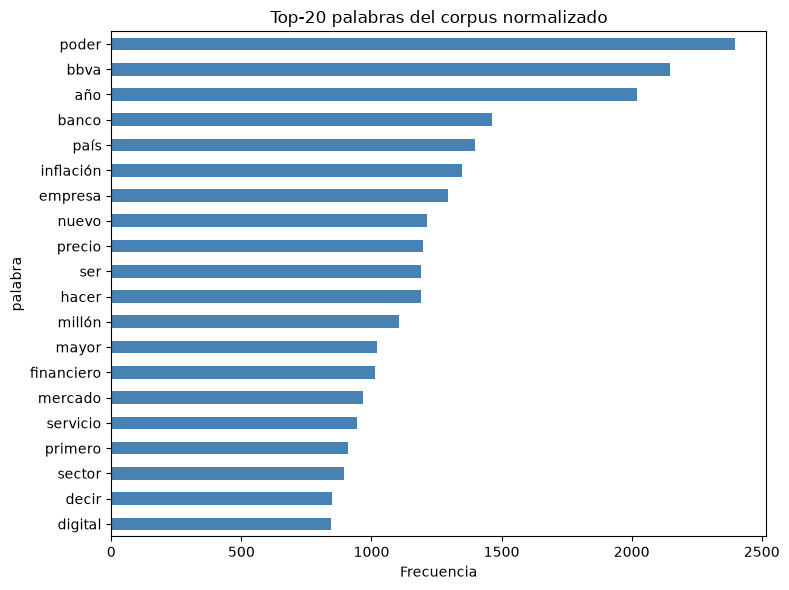

In [74]:
ax = top20.set_index("palabra")["frecuencia"].plot(
    kind="barh", figsize=(8, 6), color="steelblue"
)
ax.invert_yaxis()
ax.set_title("Top-20 palabras del corpus normalizado")
ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIG / "02_top20.png", dpi=150)
plt.show()

### 5.4 Histograma: cantidad de tokens por documento

count    1137.00
mean      263.22
std       178.54
min        27.00
25%       139.00
50%       227.00
75%       325.00
max      1479.00
Name: tok_5_lemas, dtype: float64


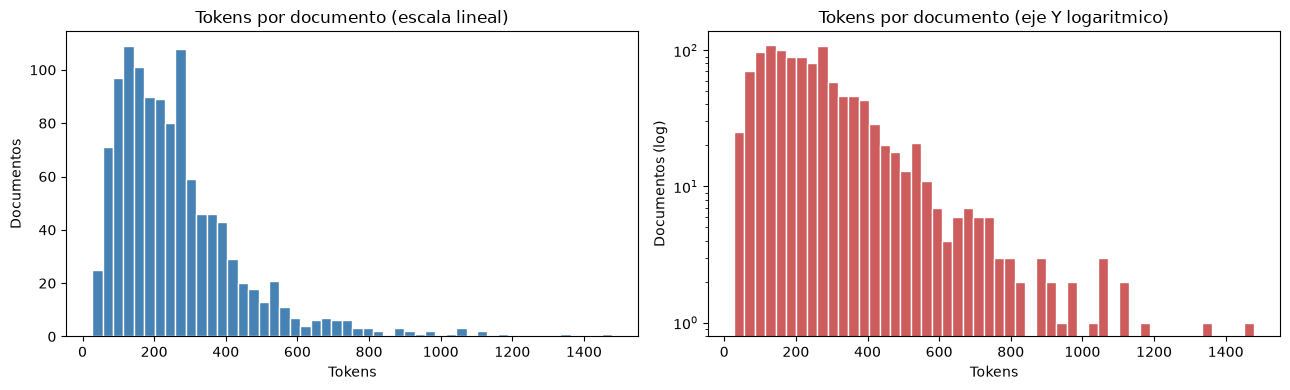


Media: 263.2 | Mediana: 227.0
Media > mediana indica cola larga a la derecha (pocas noticias muy largas).


In [75]:
longitudes = df["tok_5_lemas"].str.len()
print(longitudes.describe().round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(longitudes, bins=50, color="steelblue", edgecolor="white")
ax[0].set_title("Tokens por documento (escala lineal)")
ax[0].set_xlabel("Tokens")
ax[0].set_ylabel("Documentos")

ax[1].hist(longitudes, bins=50, color="indianred", edgecolor="white")
ax[1].set_yscale("log")
ax[1].set_title("Tokens por documento (eje Y logaritmico)")
ax[1].set_xlabel("Tokens")
ax[1].set_ylabel("Documentos (log)")

plt.tight_layout()
plt.savefig(FIG / "03_histograma_longitudes.png", dpi=150)
plt.show()

print(f"\nMedia: {longitudes.mean():.1f} | Mediana: {longitudes.median():.1f}")
print("Media > mediana indica cola larga a la derecha (pocas noticias muy largas).")

### 5.5 Ley de Zipf

Graficamos frecuencia contra rango en escala log-log y la comparamos con la curva teórica
$f(rango) \approx k / rango$, donde $k$ es la frecuencia de la palabra de rango 1.

In [76]:
def datos_zipf(contador):
    """Devuelve (rangos, frecuencias observadas, frecuencias teoricas k/rango)."""
    frecs = [f for _, f in contador.most_common()]
    rangos = list(range(1, len(frecs) + 1))
    k = frecs[0]                      # constante = frecuencia del rango 1
    teorica = [k / r for r in rangos]
    return rangos, frecs, teorica

# Tambien calculamos Zipf sobre el corpus SIN normalizar (solo tokenizado + minusculas)
# para ver el efecto de quitar las stopwords sobre la cabeza de la curva.
frecuencias_crudo = Counter(t for lista in df["tok_2_minusculas"] for t in lista)

r_n, f_n, t_n = datos_zipf(frecuencias)          # normalizado
r_c, f_c, t_c = datos_zipf(frecuencias_crudo)    # crudo

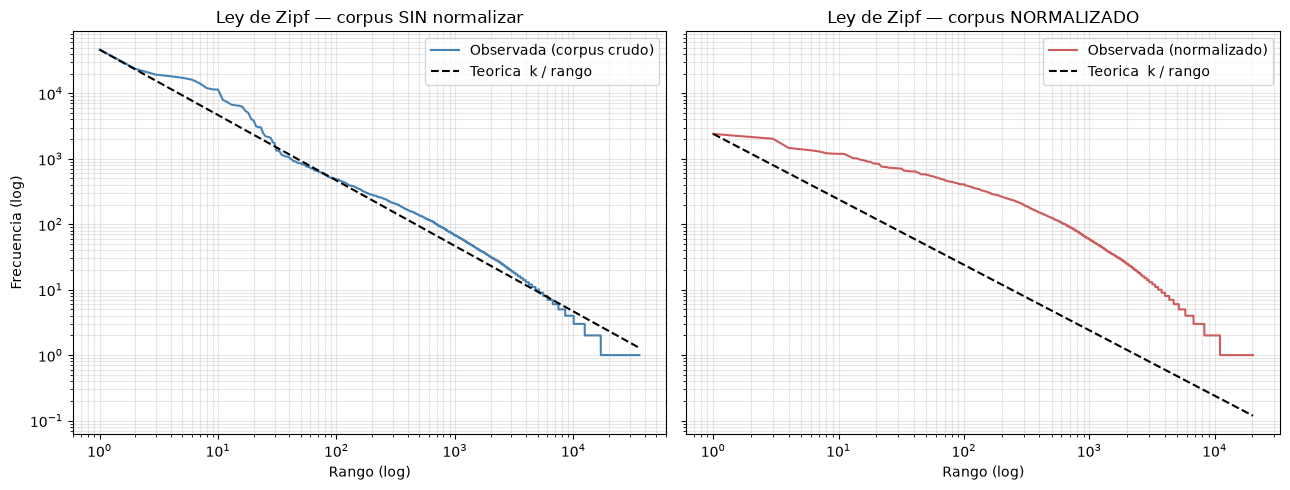

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax[0].loglog(r_c, f_c, color="steelblue", label="Observada (corpus crudo)")
ax[0].loglog(r_c, t_c, "--", color="black", label="Teorica  k / rango")
ax[0].set_title("Ley de Zipf — corpus SIN normalizar")
ax[0].set_xlabel("Rango (log)")
ax[0].set_ylabel("Frecuencia (log)")
ax[0].legend()
ax[0].grid(alpha=.3, which="both")

ax[1].loglog(r_n, f_n, color="indianred", label="Observada (normalizado)")
ax[1].loglog(r_n, t_n, "--", color="black", label="Teorica  k / rango")
ax[1].set_title("Ley de Zipf — corpus NORMALIZADO")
ax[1].set_xlabel("Rango (log)")
ax[1].legend()
ax[1].grid(alpha=.3, which="both")

plt.tight_layout()
plt.savefig(FIG / "04_zipf.png", dpi=150)
plt.show()

In [78]:
# Evidencia numerica para el analisis:
# 1) verificamos que rango x frecuencia sea aproximadamente constante
print("rango x frecuencia (corpus normalizado):")
for r in [1, 5, 10, 50, 100, 500, 1000]:
    if r <= len(f_n):
        print(f"  rango {r:>5}  frec {f_n[r-1]:>7,}  producto {r*f_n[r-1]:>10,}")

# 2) hapax legomena: palabras que aparecen UNA sola vez
hapax = sum(1 for c in frecuencias.values() if c == 1)
print(f"\nHapax legomena: {hapax:,} de {len(frecuencias):,} tipos "
      f"({hapax/len(frecuencias)*100:.1f}% del vocabulario)")

rango x frecuencia (corpus normalizado):
  rango     1  frec   2,398  producto      2,398
  rango     5  frec   1,397  producto      6,985
  rango    10  frec   1,190  producto     11,900
  rango    50  frec     573  producto     28,650
  rango   100  frec     406  producto     40,600
  rango   500  frec     126  producto     63,000
  rango  1000  frec      59  producto     59,000

Hapax legomena: 9,213 de 20,237 tipos (45.5% del vocabulario)


### 5.6 Comparación por categoría

In [79]:
top_por_categoria = {}
for categoria, grupo in df.groupby("Type"):
    c = Counter(t for lista in grupo["tok_5_lemas"] for t in lista)
    top_por_categoria[categoria] = [f"{p} ({f})" for p, f in c.most_common(10)]

comparacion = pd.DataFrame(top_por_categoria, index=range(1, 11))
comparacion.index.name = "rango"
comparacion

,Alianzas,Innovacion,Macroeconomia,Otra,Regulaciones,Reputacion,Sostenibilidad
rango,,,,,,,
1,alianza (422),bbva (886),inflación (1278),banco (387),poder (275),empresa (116),bbva (428)
2,poder (337),poder (496),precio (986),bbva (332),decir (232),reputación (83),poder (419)
3,país (330),banco (353),año (904),millón (271),regulación (230),sector (53),energía (362)
4,nuevo (254),digital (338),poder (666),financiero (217),empresa (220),año (51),sostenible (360)
5,colombia (252),cliente (324),tasa (509),año (207),país (214),país (50),agua (235)
6,año (244),nuevo (314),mayor (507),entidad (195),mercado (185),ser (47),año (231)
7,millón (242),dato (297),bbva (494),poder (164),servicio (173),hacer (47),eléctrico (228)
8,empresa (233),empresa (283),mes (488),crédito (157),hacer (171),posición (41),sostenibilidad (210)
9,hacer (200),permitir (259),país (431),cliente (142),año (170),poder (41),objetivo (208)


In [80]:
# Palabras que son exclusivas del top-10 de una sola categoria (las mas distintivas)
conjuntos = {cat: {x.split(" (")[0] for x in lst} for cat, lst in top_por_categoria.items()}
for cat, palabras in conjuntos.items():
    otras = set().union(*[v for k, v in conjuntos.items() if k != cat])
    print(f"{cat:<15} exclusivas: {sorted(palabras - otras)}")

Alianzas        exclusivas: ['alianza', 'colombia']
Innovacion      exclusivas: ['dato', 'digital', 'permitir']
Macroeconomia   exclusivas: ['aumento', 'inflación', 'mayor', 'mes', 'precio']
Otra            exclusivas: ['crédito', 'entidad']
Regulaciones    exclusivas: ['decir', 'regulación', 'servicio']
Reputacion      exclusivas: ['grupo', 'posición', 'reputación', 'sector']
Sostenibilidad  exclusivas: ['agua', 'eléctrico', 'energía', 'objetivo', 'sostenibilidad', 'sostenible']


### 5.7 Nube de palabras

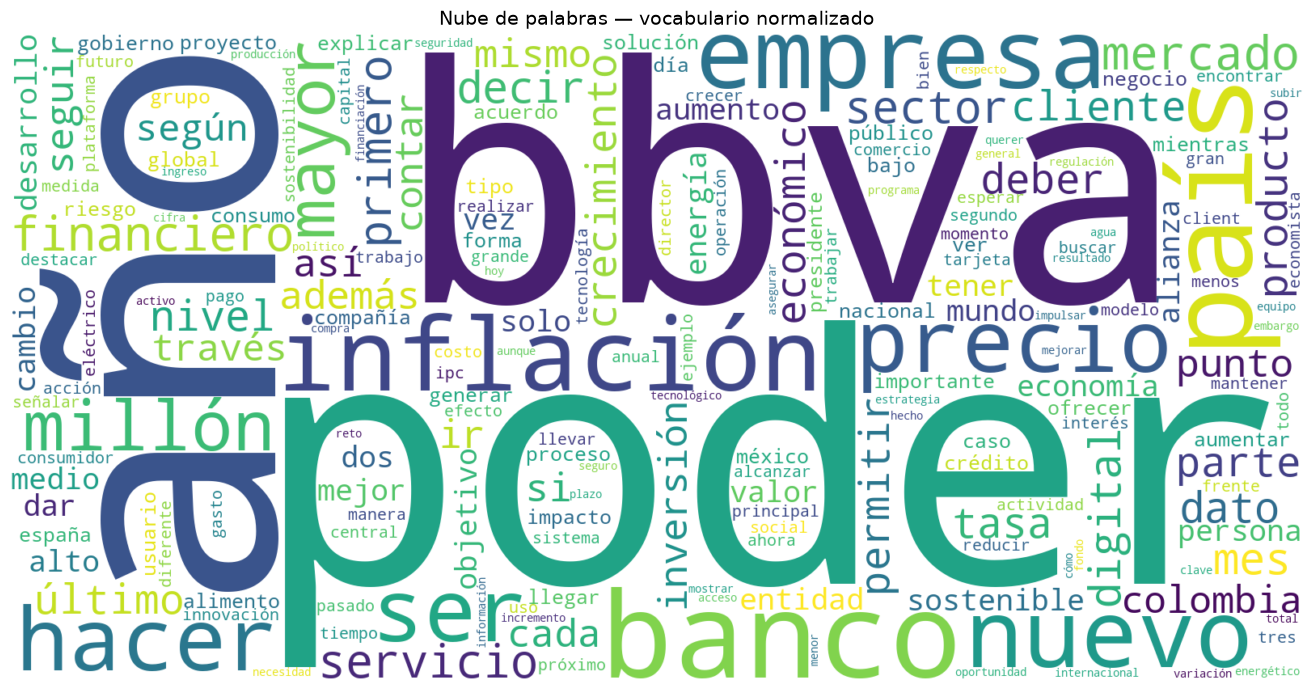

In [81]:
from wordcloud import WordCloud

# Usamos generate_from_frequencies (NO generate(texto)): ya tenemos el conteo hecho
# con nuestro pipeline, y generate() re-tokenizaria con reglas del ingles.
nube = WordCloud(
    width=1600, height=800,
    background_color="white",
    max_words=200,
    stopwords=set(),          # desactivamos la lista inglesa que trae por defecto
    colormap="viridis",
).generate_from_frequencies(frecuencias)

plt.figure(figsize=(14, 7))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — vocabulario normalizado", fontsize=14)
plt.tight_layout()
plt.savefig(FIG / "05_nube_palabras.png", dpi=150, bbox_inches="tight")
plt.show()

---

# Laboratorio #2 — Representaciones básicas de texto
**Natural Language Processing — UFM**

Continuación directa del Laboratorio #1: se reutiliza el mismo `df` ya limpio, con la columna
`tok_5_lemas` (lista de lemas por documento) y la etiqueta `Type`.


## 1. Bolsa de palabras (Bag of Words)

`CountVectorizer` recibe **texto plano**, no listas de tokens, así que primero reconstruimos
cada documento uniendo sus lemas con espacios. Así el vectorizador solo tiene que separar por
espacios y no vuelve a aplicar reglas de tokenización que ya resolvimos en el Lab #1.


In [93]:
# Texto normalizado por documento: los lemas del Lab #1 unidos en un solo string
df["texto_norm"] = df["tok_5_lemas"].str.join(" ")

df[["Type", "texto_norm"]].head(3)

,Type,texto_norm
0,Otra,foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante entender sostenibilidad poder asociar mayor costo creer tener concepto negocio sostenible poder tener mayor impacto garcía reto importante cambiar prior...
1,Regulaciones,regulador valor chino decir domingo buscar cooperación estrecho par estadounidense apoyar salida bolso extranjero luego supervisor estadounidense endurecer exigencia divulgación información empresa chino expresar preocupación medida comisión regulador valor chino csrc decir comunicado tomar nota...
2,Alianzas,industria históricamente masculino aviación vivo presentar avión rosado apostar equidad género lucha cáncer mama inclusión francia llegar go pink precio promedio millón convertir él aeronave número finalizar año vivo trabajar fuerte mujer actualmente grupo ejecutivo compuesto mujer meter llegar ...


In [94]:
from sklearn.feature_extraction.text import CountVectorizer

# Sin parametros: queremos el vocabulario COMPLETO del corpus ya normalizado.
# El texto entra pre-limpio del Lab #1, asi que el vectorizador solo separa por espacios.
vectorizador = CountVectorizer()

# fit_transform = aprende el vocabulario (fit) y construye la matriz de conteos (transform)
X_bow = vectorizador.fit_transform(df["texto_norm"])

n_docs, n_vocab = X_bow.shape
print(f"Matriz BoW: {n_docs:,} documentos x {n_vocab:,} palabras de vocabulario")
print(f"Celdas totales: {n_docs * n_vocab:,}  |  celdas con valor != 0: {X_bow.nnz:,}")

# Comparacion con el vocabulario contado a mano en el Lab #1
print(f"\nVocabulario en el Lab #1: {len(frecuencias):,}")
print(f"Vocabulario de CountVectorizer: {n_vocab:,}  diferencia: {len(frecuencias) - n_vocab:,}")

Matriz BoW: 1,137 documentos x 19,767 palabras de vocabulario
Celdas totales: 22,475,079  |  celdas con valor != 0: 202,700

Vocabulario en el Lab #1: 20,237
Vocabulario de CountVectorizer: 19,767  diferencia: 470


**Qué se pierde y qué se gana con BoW** 

Lo que se pierde es el orden, la sintaxis, el contexto y la relación en cada uno ya que se dan vectores idénticos haciendo que se pierda el sentido acorde a la estructura de la oración, como bag of words toma todas las dimensiones de forma independiente muchas palabras importantes pierden relación entre sí.


Lo que se gana es una representación numérica de tamaño fijo que permite compararla entre sí sin importar el tamaño de la noticia. Es más baráta de consumir en cuento a costo computacional ya que con una pasada sobre el corpus ya se puede interpretar con cada columna correspondiendo a cada palabra en concreto para ver directamente que se relaciona con qué en cada documento.
